# Conditional Routing




## Install dependencies
Run this once in a fresh environment.


In [1]:
# %pip -q install langgraph langchain-openai python-dotenv

## 1) Imports

In [2]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal

## 2) Load environment variables - please read instructions carefully

In [3]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [4]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) Define Node

In [5]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.4
)

# llm = ChatOpenAI(
#     model="gpt-4.1-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.4
# )

class State(TypedDict):
    query: str
    route: str
    answer: str


def classify_intent(state: State):
    query = state["query"]

    response = llm.invoke(f"""
Classify this query into exactly one category:

technical
billing
general

Query: {query}

Return only one word.
""")

    route = response.content.strip().lower()

    if route not in ["technical", "billing", "general"]:
        route = "general"

    return {"route": route}


def route_decision(state: State) -> Literal["technical", "billing", "general"]:
    return state["route"]


def handle_technical(state: State):
    response = llm.invoke(
        f"You are a technical support expert. Answer this:\n{state['query']}"
    )
    return {"answer": response.content}


def handle_billing(state: State):
    response = llm.invoke(
        f"You are a billing support agent. Answer this:\n{state['query']}"
    )
    return {"answer": response.content}


def handle_general(state: State):
    response = llm.invoke(
        f"Answer this general question:\n{state['query']}"
    )
    return {"answer": response.content}




## 4) Build the conditional router

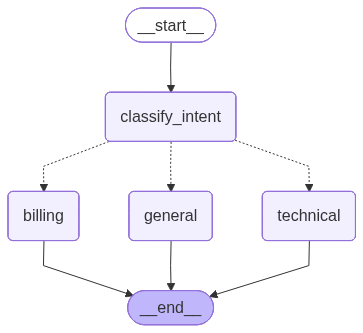

In [6]:
builder = StateGraph(State)

builder.add_node("classify_intent", classify_intent)
builder.add_node("technical", handle_technical)
builder.add_node("billing", handle_billing)
builder.add_node("general", handle_general)

builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_decision,
    {
        "technical": "technical",
        "billing": "billing",
        "general": "general",
    }
)

builder.add_edge("technical", END)
builder.add_edge("billing", END)
builder.add_edge("general", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 4) Run

In [7]:
result = graph.invoke({
    "query": "I was charged twice this month. Can you help?"
})

print(result["route"])
print(result["answer"])

billing
I'm sorry to hear that you were charged twice this month. I’d be happy to help you with this. Could you please provide me with your account details or the transaction dates and amounts so I can look into it for you?
